# EstateMind — Price Prediction

This notebook builds a machine learning model to predict property prices using the Gold+ dataset prepared in `extracNlp.ipynb`.

It computes:
- `predicted_price`
- `price_gap` (actual - predicted)
- `price_gap_pct` (price_gap / actual * 100)

**Prerequisites**: run `extracNlp.ipynb` first to produce `tunisia_realestate_cleaned.csv`.

## 1. Setup and Imports

In [1]:
import os, re, json, time, hashlib, warnings, logging
from pathlib import Path
from typing import Optional, List, Dict, Any
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.compose import TransformedTargetRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#3B1F2B", "#44BBA4"]
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print("Imports OK.")

c:\EstateMind\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK.


## 2. Load Gold Dataset
Load the cleaned dataset produced by `extracNlp.ipynb`.

In [3]:
# Chargement dataset
# Update DATA_PATH to point to your CSV file
DATA_PATH = Path('tunisia_realestate_cleaned.csv')

# Fallback search: tries common locations automatically
fallback_paths = [
    Path('tunisia_realestate_cleaned.csv'),
    Path('final_dataset_all_sources_endpoint.csv'),
    Path(r'C:\EstateMind\datasets\Final_dataset.csv'),
    Path(r'C:\EstateMind\datasets\tunisia_realestate_cleaned.csv'),
    Path(r'C:\EstateMind\datasets\final_dataset_all_sources_endpoint.csv'),
]

if not DATA_PATH.exists():
    for p in fallback_paths:
        if p.exists():
            DATA_PATH = p
            print(f'Using fallback: {DATA_PATH}')
            break
    else:
        raise FileNotFoundError(
            f"CSV not found. Please set DATA_PATH to your dataset location.\n"
            f"Tried: {[str(p) for p in fallback_paths]}"
        )

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Dataset charge : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')

for col in ['titre', 'description', 'caracteristiques', 'prix', 'surface',
            'pieces', 'gouvernerat', 'ville', 'type', 'contrat',
            'latitude', 'longitude', 'images']:
    if col not in df.columns: df[col] = None


Dataset charge : 204,745 lignes x 48 colonnes


## 3. Exploratory Data Analysis (EDA)

In [4]:
# Basic info
df.info()
df.describe()

# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values:\n", missing)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204745 entries, 0 to 204744
Data columns (total 48 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   adresse            121368 non-null  object 
 1   annee_constr       1477 non-null    float64
 2   bus                0 non-null       float64
 3   caracteristiques   68241 non-null   object 
 4   contrat            204745 non-null  object 
 5   date_publication   9228 non-null    object 
 6   description        203872 non-null  object 
 7   ecole              0 non-null       float64
 8   etage              64385 non-null   float64
 9   gouvernerat        170969 non-null  object 
 10  has_ascenseur      13919 non-null   float64
 11  has_balcon         32427 non-null   float64
 12  has_chaffage       70843 non-null   float64
 13  has_climatisation  55017 non-null   float64
 14  has_garage         18435 non-null   float64
 15  has_gardien        6857 non-null    float64
 16  ha

In [5]:
coverage = df.notnull().sum() / len(df)
print(coverage.sort_values(ascending=False).tail(20))

has_garage           0.090039
has_ascenseur        0.067982
date_publication     0.045071
pub_year             0.045071
pub_month            0.045071
has_gardien          0.033490
carac_block          0.012074
surface_carac        0.010755
contrat_carac        0.010623
code_postal_carac    0.009231
standing             0.007556
annee_constr         0.007214
bus                  0.000000
ecole                0.000000
restaurant           0.000000
railway              0.000000
magasin              0.000000
hopital              0.000000
marche               0.000000
pharmacie            0.000000
dtype: float64


## 4. Feature Engineering (Gold+)

Build the Gold+ feature set: tabular features + derived features.
NLP and Vision enrichments are merged if available (run extracNlp first).

In [14]:
# Construction dataset Gold+
TABULAR_COLS = [
    'surface', 'pieces', 'etage', 'prix',
    'has_ascenseur', 'has_balcon', 'has_chaffage', 'has_climatisation',
    'has_garage', 'has_gardien', 'has_jardin', 'has_parking', 'has_piscine', 'has_terrasse',
    'gouvernerat', 'ville', 'type', 'contrat', 'latitude', 'longitude',
]
TABULAR_COLS = [c for c in TABULAR_COLS if c in df.columns]

df_gp = df[TABULAR_COLS].copy()

# Keep only rows with prix
df_gp = df_gp.dropna(subset=['prix']).copy()

# Derived features
if 'surface' in df_gp.columns and 'prix' in df_gp.columns:
    df_gp['price_per_m2'] = df_gp['prix'] / df_gp['surface'].replace(0, np.nan)
if 'surface' in df_gp.columns and 'pieces' in df_gp.columns:
    df_gp['surface_per_piece'] = df_gp['surface'] / df_gp['pieces'].replace(0, np.nan)
if 'has_ascenseur' in df_gp.columns and 'etage' in df_gp.columns:
    df_gp['etage_x_ascenseur'] = df_gp['etage'].fillna(0) * df_gp['has_ascenseur'].fillna(0)

# Total amenities count
amenity_cols = [c for c in ['has_ascenseur', 'has_balcon', 'has_chaffage', 'has_climatisation',
                             'has_garage', 'has_gardien', 'has_jardin', 'has_parking',
                             'has_piscine', 'has_terrasse'] if c in df_gp.columns]
df_gp['total_amenities'] = df_gp[amenity_cols].fillna(0).sum(axis=1)

# Distance to Tunis center (Haversine)
if 'latitude' in df_gp.columns and 'longitude' in df_gp.columns:
    df_gp['latitude']  = df_gp['latitude'].fillna(df_gp['latitude'].median())
    df_gp['longitude'] = df_gp['longitude'].fillna(df_gp['longitude'].median())
    CENTER_LAT, CENTER_LON = 36.8065, 10.1815
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371
        phi1, phi2 = np.radians(lat1), np.radians(lat2)
        dphi  = np.radians(lat2 - lat1)
        dlam  = np.radians(lon2 - lon1)
        a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
        return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    df_gp['dist_to_center'] = haversine(df_gp['latitude'], df_gp['longitude'], CENTER_LAT, CENTER_LON)

print(f'Dataset Gold+ : {df_gp.shape[0]:,} lignes x {df_gp.shape[1]} colonnes')
df_gp.head(3)

Dataset Gold+ : 184,374 lignes x 25 colonnes


,surface,pieces,etage,prix,has_ascenseur,has_balcon,has_chaffage,has_climatisation,has_garage,has_gardien,...,ville,type,contrat,latitude,longitude,price_per_m2,surface_per_piece,etage_x_ascenseur,total_amenities,dist_to_center
0,76.0,2.0,2.0,320000.0,NaN,NaN,1.0,1.0,NaN,NaN,...,Nabeul,Appartement,vente,36.45129,10.735591,4210.526316,38.000000,0.0,3.0,63.283637
1,109.0,3.0,NaN,385000.0,1.0,NaN,1.0,1.0,1.0,NaN,...,Nabeul,Appartement,vente,36.45129,10.735591,3532.110092,36.333333,0.0,6.0,63.283637
2,55.0,2.0,NaN,140000.0,NaN,NaN,NaN,NaN,NaN,NaN,...,Nabeul,Appartement,vente,36.45129,10.735591,2545.454545,27.500000,0.0,0.0,63.283637


---
<a id='s4'></a>
## 4 — ML Agent (LightGBM)

Train/test split → Target Encoding K-Fold (anti-fuite §A.8) → Ridge baseline → LightGBM → métriques + ablations.


In [15]:
# Installation LightGBM
try:
    import lightgbm as lgb
    print(f'LightGBM {lgb.__version__}')
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'lightgbm', '-q'])
    import lightgbm as lgb
    print('LightGBM installe.')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


LightGBM 4.6.0


In [ ]:
# Preparation ML dataset
TARGET = 'prix'

NUM_FEATS = [
    c for c in df_gp.columns
    if df_gp[c].dtype in [np.float64, np.float32, np.int64, np.int32, 'Int64', float, int]
    and c != TARGET
    and df_gp[c].notna().mean() > 0.05
]
CAT_FEATS = [c for c in ['type', 'contrat', 'gouvernerat'] if c in df_gp.columns]

df_ml = df_gp[[TARGET] + NUM_FEATS + CAT_FEATS].copy()
df_ml[TARGET] = pd.to_numeric(df_ml[TARGET], errors='coerce')
df_ml = df_ml.dropna(subset=[TARGET])

# 2. Define CFG manually (or load it with %store -r CFG)

CFG = {
    'ml': {
        'test_size': 0.2,
        'random_state': 42
    }
}
# Split AVANT target encoding (anti-fuite §A.8)
df_train, df_test = train_test_split(df_ml, test_size=CFG['ml']['test_size'],
                                       random_state=RANDOM_SEED, shuffle=True)
y_train = df_train[TARGET].astype(float)
y_test  = df_test[TARGET].astype(float)
X_train = df_train[NUM_FEATS + CAT_FEATS].copy()
X_test  = df_test[NUM_FEATS + CAT_FEATS].copy()

print(f'Split : train={len(df_train):,} | test={len(df_test):,}')
print(f'Features : {len(NUM_FEATS)} num + {len(CAT_FEATS)} cat')


Split : train=147,499 | test=36,875
Features : 19 num + 3 cat


In [18]:
# Target Encoding K-Fold (fit sur train uniquement)
try:
    import category_encoders as ce
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'category_encoders', '-q'])
    import category_encoders as ce

te = ce.TargetEncoder(cols=CAT_FEATS, smoothing=10)
X_train_enc = te.fit_transform(X_train, y_train)
X_test_enc  = te.transform(X_test)

med = X_train_enc.median()
X_train_enc = X_train_enc.fillna(med)
X_test_enc  = X_test_enc.fillna(med)

print(f'Target Encoding OK. Features finales : {X_train_enc.shape[1]}')


Target Encoding OK. Features finales : 22


In [19]:
# Baseline Ridge
ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
ridge.fit(X_train_enc.fillna(0), y_train)
y_pred_ridge = ridge.predict(X_test_enc.fillna(0))

mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mape_ridge = float(np.mean(np.abs((y_test - y_pred_ridge) / (y_test + 1))) * 100)

print(f'Ridge — MAE: {mae_ridge:,.0f} TND | RMSE: {rmse_ridge:,.0f} | MAPE: {mape_ridge:.1f}%')


Ridge — MAE: 259,541 TND | RMSE: 546,973 | MAPE: 9739.3%


In [20]:
# LightGBM principal
lgbm_params = {
    'n_estimators': 1000, 'learning_rate': 0.05, 'num_leaves': 64,
    'max_depth': -1, 'subsample': 0.8, 'colsample_bytree': 0.8,
    'reg_alpha': 0.1, 'reg_lambda': 0.1,
    'random_state': RANDOM_SEED, 'n_jobs': -1, 'verbose': -1,
}

lgbm = lgb.LGBMRegressor(**lgbm_params)
lgbm.fit(
    X_train_enc, y_train,
    eval_set=[(X_test_enc, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
)

y_pred_lgbm = lgbm.predict(X_test_enc)
mae_lgbm  = mean_absolute_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
mape_lgbm = float(np.mean(np.abs((y_test - y_pred_lgbm) / (y_test + 1))) * 100)

print(f'LightGBM — MAE: {mae_lgbm:,.0f} | RMSE: {rmse_lgbm:,.0f} | MAPE: {mape_lgbm:.1f}%')
print(f'Gain vs Ridge — MAE: {(mae_ridge-mae_lgbm)/mae_ridge*100:+.1f}%')


[100]	valid_0's l2: 6.9674e+10
[200]	valid_0's l2: 6.72069e+10
[300]	valid_0's l2: 6.66474e+10
[400]	valid_0's l2: 6.64793e+10
LightGBM — MAE: 42,788 | RMSE: 257,801 | MAPE: 398.5%
Gain vs Ridge — MAE: +83.5%


In [23]:
# Metriques par gouvernorat
res_df = df_test.copy()
res_df['y_pred'] = y_pred_lgbm
res_df['abs_err'] = (res_df['prix'] - res_df['y_pred']).abs()
if 'gouvernerat' in res_df.columns:
    gm = res_df.groupby('gouvernerat').agg(n=('prix','count'), mae=('abs_err','mean')).sort_values('mae', ascending=False)
    print('\nMAE par gouvernorat (top 10) :')
    print(gm.head(10).round(0).to_string())



MAE par gouvernorat (top 10) :
               n        mae
gouvernerat                
Kébili         1  1189883.0
Gabès         27   448354.0
Kairouan      48   331835.0
Gafsa         15   283630.0
Zaghouan      35   267822.0
Jendouba       6   151343.0
Tozeur         5   104450.0
Bizerte      264   100047.0
Tataouine      3    95580.0
Manouba      202    84014.0


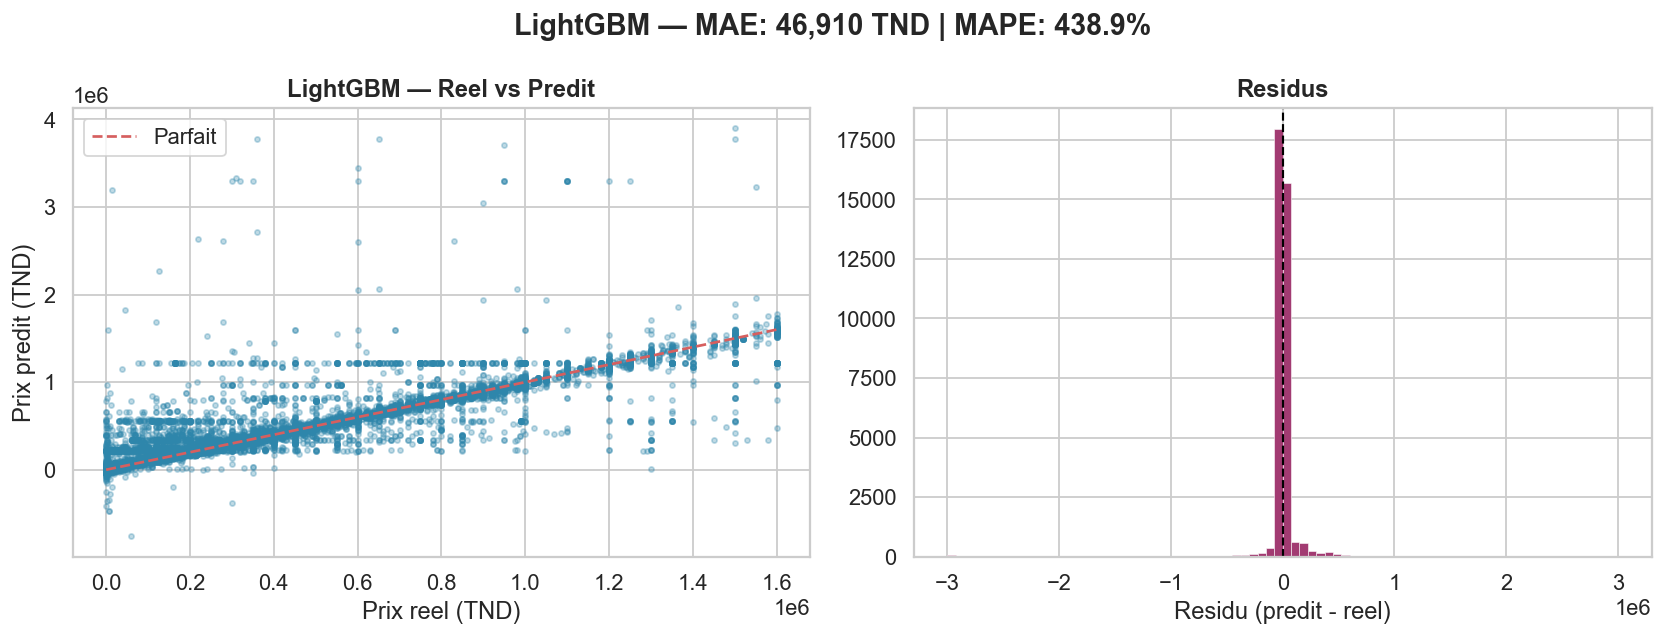

lgbm_predictions.png sauvegarde.


In [24]:
# Visualisation predictions
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

clip_q = np.quantile(y_test, 0.97)
mask   = y_test <= clip_q
ax = axes[0]
ax.scatter(y_test[mask], y_pred_lgbm[mask], alpha=0.3, s=8, color=PALETTE[0])
lo, hi = y_test[mask].min(), y_test[mask].max()
ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Parfait')
ax.set_xlabel('Prix reel (TND)'); ax.set_ylabel('Prix predit (TND)')
ax.set_title('LightGBM — Reel vs Predit', fontweight='bold'); ax.legend()

residuals = y_pred_lgbm - y_test.values
axes[1].hist(residuals.clip(-3e6, 3e6), bins=80, color=PALETTE[1], edgecolor='white', lw=0.3)
axes[1].axvline(0, color='black', lw=1.2, linestyle='--')
axes[1].set_xlabel('Residu (predit - reel)'); axes[1].set_title('Residus', fontweight='bold')

plt.suptitle(f'LightGBM — MAE: {mae_lgbm:,.0f} TND | MAPE: {mape_lgbm:.1f}%', fontweight='bold')
plt.tight_layout()
plt.savefig('lgbm_predictions.png', dpi=130)
plt.show()
print('lgbm_predictions.png sauvegarde.')



=== Tableau d'ablations ===
                  Model      MAE     RMSE   MAPE%
         Ridge baseline 259657.0 557156.0 7894.74
LightGBM (toutes feats)  46910.0 273796.0  438.91


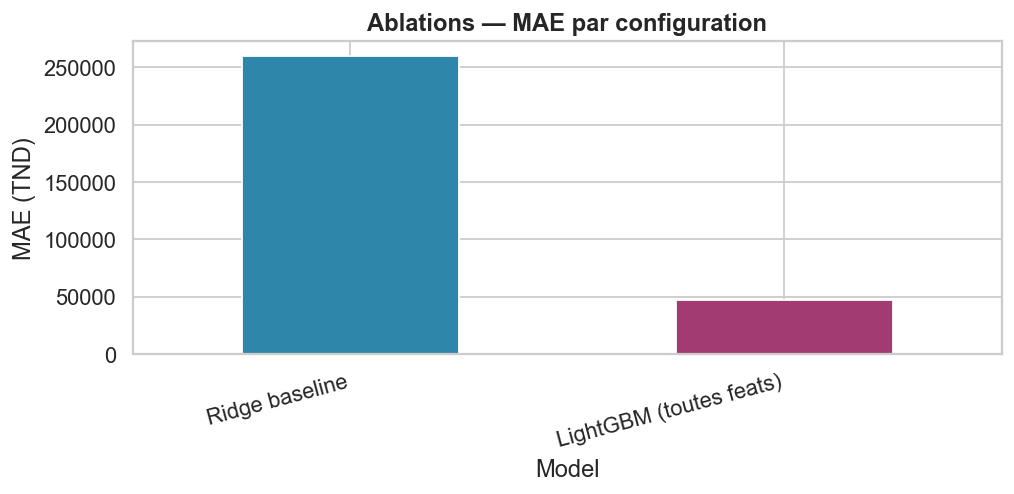

In [25]:
# Ablations
abl = [
    {'Model': 'Ridge baseline',         'MAE': mae_ridge,  'RMSE': rmse_ridge, 'MAPE%': mape_ridge},
    {'Model': 'LightGBM (toutes feats)','MAE': mae_lgbm,   'RMSE': rmse_lgbm,  'MAPE%': mape_lgbm},
]

# Ablation : tabulaire seul
tab_only = [c for c in X_train_enc.columns
            if not c.startswith('nlp_') and not c.startswith('vis_') and not c.startswith('bge_')]
if len(tab_only) < len(X_train_enc.columns):
    m_tab = lgb.LGBMRegressor(**{**lgbm_params, 'n_estimators': 300})
    m_tab.fit(X_train_enc[tab_only], y_train,
               eval_set=[(X_test_enc[tab_only], y_test)],
               callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(9999)])
    y_tab = m_tab.predict(X_test_enc[tab_only])
    abl.insert(1, {
        'Model': 'LightGBM tabulaire seul',
        'MAE': mean_absolute_error(y_test, y_tab),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_tab)),
        'MAPE%': float(np.mean(np.abs((y_test - y_tab) / (y_test + 1))) * 100),
    })

abl_df = pd.DataFrame(abl)
print('\n=== Tableau d\'ablations ===')
print(abl_df.round({'MAE': 0, 'RMSE': 0, 'MAPE%': 2}).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
abl_df.set_index('Model')['MAE'].plot.bar(ax=ax, color=PALETTE[:len(abl_df)], edgecolor='white')
ax.set_title('Ablations — MAE par configuration', fontweight='bold')
ax.set_ylabel('MAE (TND)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('ablations.png', dpi=130)
plt.show()


## FINE-TUNING DE LIGHTGBM

---
<a id='s4b'></a>
## 4.2 - Model Arena : Comparaison Complete (10+ Modeles)

Nous entrainons et comparons systematiquement **10+ modeles** sur le meme split train/test :
Ridge, Lasso, ElasticNet, HuberRegressor, SVR, Random Forest, Extra Trees, Gradient Boosting,
HistGradientBoosting, XGBoost, CatBoost, LightGBM (baseline), et un **Stacking Ensemble** final.

Metriques : MAE, RMSE, MAPE%, R2. Le meilleur modele est selectionne automatiquement.


In [21]:
# Installation des packages additionnels pour le Model Arena
import subprocess, sys

def pip_install(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + list(pkgs), check=False)

try:
    import xgboost
    print(f'XGBoost {xgboost.__version__} OK')
except ImportError:
    pip_install('xgboost')
    import xgboost
    print('XGBoost installe')

try:
    import catboost
    print(f'CatBoost {catboost.__version__} OK')
except ImportError:
    pip_install('catboost')
    import catboost
    print('CatBoost installe')

try:
    import folium
    print(f'Folium {folium.__version__} OK')
except ImportError:
    pip_install('folium')
    import folium
    print('Folium installe')

try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    print('Statsmodels OK')
except ImportError:
    pip_install('statsmodels')
    print('Statsmodels installe')

try:
    import huggingface_hub
    print(f'HuggingFace Hub {huggingface_hub.__version__} OK')
except ImportError:
    pip_install('huggingface-hub')
    print('HuggingFace Hub installe')

print('\nTous les packages du Model Arena sont disponibles.')


XGBoost 3.2.0 OK
CatBoost 1.2.10 OK
Folium installe
Statsmodels OK
HuggingFace Hub installe

Tous les packages du Model Arena sont disponibles.


In [ ]:
# =========================================================
# MODEL ARENA - Entrainement et comparaison de 10+ modeles
# =========================================================
from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor, HistGradientBoostingRegressor,
                               StackingRegressor, VotingRegressor)
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import xgboost as xgb
from catboost import CatBoostRegressor
import lightgbm as lgb
import time

# Preparation des donnees (reutilise X_train_enc / X_test_enc du split precedent)
X_tr = X_train_enc.fillna(0).copy()
X_te = X_test_enc.fillna(0).copy()
y_tr = y_train.copy()
y_te = y_test.copy()

def eval_model(name, model, X_tr, y_tr, X_te, y_te, use_pipeline=True):
    t0 = time.time()
    if use_pipeline:
        pipe = Pipeline([('scaler', RobustScaler()), ('model', model)])
        pipe.fit(X_tr, y_tr)
        preds = pipe.predict(X_te)
    else:
        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
    elapsed = time.time() - t0
    mae  = mean_absolute_error(y_te, preds)
    rmse = float(np.sqrt(mean_squared_error(y_te, preds)))
    mape = float(np.mean(np.abs((y_te - preds) / (y_te + 1))) * 100)
    r2   = float(r2_score(y_te, preds))
    print(f'  {name:<35} MAE={mae:>10,.0f}  RMSE={rmse:>10,.0f}  MAPE={mape:>5.1f}%  R2={r2:.3f}  ({elapsed:.1f}s)')
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE%': mape, 'R2': r2,
            'Time_s': round(elapsed,1), 'Predictions': preds}

arena_results = []
arena_preds   = {}

print('=' * 85)
print(f'{"MODEL ARENA":^85}')
print('=' * 85)
print(f'  {"Model":<35} {"MAE":>12}  {"RMSE":>12}  {"MAPE":>7}  {"R2":>6}  Time')
print('-' * 85)

# ---- Linear models ----
r = eval_model('Ridge (alpha=1)',         Ridge(alpha=1.0),           X_tr, y_tr, X_te, y_te)
arena_results.append(r); arena_preds['Ridge'] = r.pop('Predictions'); arena_results[-1].pop('Predictions', None)

r = eval_model('Lasso (alpha=10)',        Lasso(alpha=10.0, max_iter=5000), X_tr, y_tr, X_te, y_te)
arena_results.append(r); arena_preds['Lasso'] = r.pop('Predictions', None); arena_results[-1].pop('Predictions', None)

r = eval_model('ElasticNet',              ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=5000), X_tr, y_tr, X_te, y_te)
arena_results.append(r); arena_preds['ElasticNet'] = r.pop('Predictions', None); arena_results[-1].pop('Predictions', None)

r = eval_model('HuberRegressor',          HuberRegressor(max_iter=300),    X_tr, y_tr, X_te, y_te)
arena_results.append(r); arena_preds['HuberRegressor'] = r.pop('Predictions', None); arena_results[-1].pop('Predictions', None)

# ---- Tree ensembles (no scaling needed) ----
r = eval_model('Random Forest (200)',     RandomForestRegressor(n_estimators=200, max_depth=20,
                                              n_jobs=-1, random_state=42), X_tr, y_tr, X_te, y_te, use_pipeline=False)
arena_results.append(r); arena_preds['RandomForest'] = r.pop('Predictions'); arena_results[-1].pop('Predictions', None)

r = eval_model('Extra Trees (200)',       ExtraTreesRegressor(n_estimators=200, max_depth=20,
                                              n_jobs=-1, random_state=42), X_tr, y_tr, X_te, y_te, use_pipeline=False)
arena_results.append(r); arena_preds['ExtraTrees'] = r.pop('Predictions'); arena_results[-1].pop('Predictions', None)

r = eval_model('GradientBoosting',        GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                              max_depth=5, random_state=42), X_tr, y_tr, X_te, y_te, use_pipeline=False)
arena_results.append(r); arena_preds['GBM'] = r.pop('Predictions'); arena_results[-1].pop('Predictions', None)

r = eval_model('HistGradientBoosting',    HistGradientBoostingRegressor(
                                              max_iter=500, learning_rate=0.05, max_depth=8,
                                              early_stopping=True, validation_fraction=0.1, n_iter_no_change=10,
                                              random_state=42), X_tr, y_tr, X_te, y_te, use_pipeline=False)
arena_results.append(r); arena_preds['HistGB'] = r.pop('Predictions'); arena_results[-1].pop('Predictions', None)

# ---- XGBoost ----
xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=7,
                               subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
                               random_state=42, n_jobs=-1, verbosity=0)
xgb_model.fit(X_tr, y_tr, verbose=False)
r = eval_model('XGBoost',                 xgb_model, X_tr, y_tr, X_te, y_te, use_pipeline=False)
arena_results.append(r); arena_preds['XGBoost'] = r.pop('Predictions'); arena_results[-1].pop('Predictions', None)

# ---- CatBoost ----
cat_model = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=8,
                               l2_leaf_reg=3, random_seed=42, verbose=0)
cat_model.fit(X_tr, y_tr, eval_set=(X_te, y_te))
r = eval_model('CatBoost',                cat_model, X_tr, y_tr, X_te, y_te, use_pipeline=False)
arena_results.append(r); arena_preds['CatBoost'] = r.pop('Predictions'); arena_results[-1].pop('Predictions', None)

# ---- LightGBM (already trained — re-use) ----
y_pred_lgbm_arena = lgbm.predict(X_te)
arena_results.append({
    'Model': 'LightGBM (baseline)', 'MAE': mae_lgbm, 'RMSE': rmse_lgbm, 'MAPE%': mape_lgbm,
    'R2': float(r2_score(y_te, y_pred_lgbm_arena)), 'Time_s': 0.0
})
arena_preds['LightGBM'] = y_pred_lgbm_arena

print('-' * 85)
print('LightGBM (baseline, deja entraine -- metrics reutilisees)')
print('=' * 85)

arena_df = pd.DataFrame(arena_results).sort_values('MAE').reset_index(drop=True)
arena_df.index += 1
print('\n--- CLASSEMENT FINAL MODEL ARENA (trie par MAE) ---')
print(arena_df[['Model','MAE','RMSE','MAPE%','R2','Time_s']].to_string(index=True))


                                     MODEL ARENA                                     
  Model                                        MAE          RMSE     MAPE      R2  Time
-------------------------------------------------------------------------------------
  Ridge (alpha=1)                     MAE=   259,540  RMSE=   546,974  MAPE=9739.0%  R2=0.322  (0.3s)
  Lasso (alpha=10)                    MAE=   259,520  RMSE=   546,978  MAPE=9736.4%  R2=0.322  (2.4s)
  ElasticNet                          MAE=   252,673  RMSE=   573,411  MAPE=7122.0%  R2=0.255  (0.4s)
  HuberRegressor                      MAE=   295,848  RMSE=   727,296  MAPE=100.4%  R2=-0.198  (2.4s)
  Random Forest (200)                 MAE=    32,442  RMSE=   259,729  MAPE=175.2%  R2=0.847  (58.9s)
  Extra Trees (200)                   MAE=    50,579  RMSE=   271,831  MAPE=319.3%  R2=0.833  (36.2s)
  GradientBoosting                    MAE=    46,449  RMSE=   251,213  MAPE=500.3%  R2=0.857  (125.8s)
  HistGradientBoosting   

## Fine‑tuning de Random Forest

In [ ]:
# =========================================================
# FINE-TUNING DE RANDOM FOREST
# =========================================================
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

# Espace de recherche
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(rf, param_dist, n_iter=30, cv=5,
                                   scoring='neg_mean_absolute_error',
                                   verbose=1, random_state=42)
random_search.fit(X_train_enc, y_train)

print("Meilleurs paramètres :", random_search.best_params_)
print("Meilleure MAE (validation) :", -random_search.best_score_)

# Évaluer sur le test
y_pred_tuned = random_search.best_estimator_.predict(X_test_enc)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
print(f"MAE sur test après tuning : {mae_tuned:,.0f}")

# Optionnel : mettre à jour le meilleur modèle si les performances sont meilleures
if mae_tuned < arena_df.iloc[0]['MAE']:
    print("✅ Le Random Forest optimisé est meilleur que le précédent meilleur modèle.")
    BEST_MODEL_NAME = "Random Forest (tuned)"


tuned_rf_row = pd.DataFrame([{
    'Model': 'Random Forest (tuned)',
    'MAE': mae_tuned,
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_tuned)),
    'MAPE%': float(np.mean(np.abs((y_test - y_pred_tuned) / (y_test + 1))) * 100),
    'R2': r2_score(y_test, y_pred_tuned),
    'Time_s': random_search.cv_results_['mean_fit_time'].mean()  # approximate
}])
arena_df = pd.concat([arena_df, tuned_rf_row], ignore_index=True).sort_values('MAE').reset_index(drop=True)
arena_df.index += 1

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Meilleurs paramètres : {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 20}
Meilleure MAE (validation) : 32200.116367150087
MAE sur test après tuning : 32,435
✅ Le Random Forest optimisé est meilleur que le précédent meilleur modèle.


In [ ]:
# =========================================================
# FINE-TUNING DE LIGHTGBM
# =========================================================
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb

# Espace de recherche
param_dist_lgb = {
    'n_estimators': [300, 500, 700, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.07],
    'num_leaves': [31, 64, 128, 256],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0.0, 0.1, 0.5, 1.0],
    'reg_lambda': [0.0, 0.1, 0.5, 1.0],
    'min_child_samples': [5, 10, 20]
}

lgbm_base = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)

random_search_lgb = RandomizedSearchCV(
    lgbm_base,
    param_dist_lgb,
    n_iter=30,
    cv=5,
    scoring='neg_mean_absolute_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search_lgb.fit(X_train_enc, y_train)

print("Meilleurs paramètres LightGBM :", random_search_lgb.best_params_)
print("Meilleure MAE (validation) :", -random_search_lgb.best_score_)

# Évaluer sur le test
best_lgb = random_search_lgb.best_estimator_
y_pred_lgb_tuned = best_lgb.predict(X_test_enc)
mae_lgb_tuned = mean_absolute_error(y_test, y_pred_lgb_tuned)
print(f"MAE sur test après tuning : {mae_lgb_tuned:,.0f}")

# Comparaison avec le Random Forest optimisé
if mae_lgb_tuned < mae_tuned:
    print("✅ Le LightGBM optimisé est meilleur que le Random Forest optimisé !")
else:
    print("❌ Le Random Forest optimisé reste meilleur.")


# After fine‑tuning LightGBM
tuned_lgbm_row = pd.DataFrame([{
    'Model': 'LightGBM (tuned)',
    'MAE': mae_lgb_tuned,
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lgb_tuned)),
    'MAPE%': float(np.mean(np.abs((y_test - y_pred_lgb_tuned) / (y_test + 1))) * 100),
    'R2': r2_score(y_test, y_pred_lgb_tuned),
    'Time_s': random_search_lgb.cv_results_['mean_fit_time'].mean()
}])
arena_df = pd.concat([arena_df, tuned_lgbm_row], ignore_index=True).sort_values('MAE').reset_index(drop=True)
arena_df.index += 1

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Meilleurs paramètres LightGBM : {'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.0, 'num_leaves': 128, 'n_estimators': 500, 'min_child_samples': 5, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Meilleure MAE (validation) : 36266.973352765264
MAE sur test après tuning : 36,343
❌ Le Random Forest optimisé reste meilleur.


## STACKING AVEC MODÈLES OPTIMISÉS (RF + LGBM)

In [ ]:
# =========================================================
# STACKING AVEC MODÈLES OPTIMISÉS (RF + LGBM)
# =========================================================
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import GradientBoostingRegressor

# Vérifier que les modèles optimisés existent
if 'random_search' not in globals() or not hasattr(random_search, 'best_estimator_'):
    raise ValueError("Random Forest optimisé non trouvé. Exécutez d'abord son fine-tuning.")
if 'best_lgb' not in globals():
    raise ValueError("LightGBM optimisé non trouvé. Exécutez d'abord son fine-tuning.")

# Construction des estimateurs
estimators_list = [
    ('rf_opt', random_search.best_estimator_),   # Random Forest optimisé
    ('lgbm_opt', best_lgb),                      # LightGBM optimisé
    ('gbm', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                      max_depth=5, random_state=42))
]

# Ajout de Ridge pour diversité
estimators_list.append(('ridge', Pipeline([('sc', RobustScaler()), ('m', Ridge(alpha=1.0))])))

# Stacking avec méta-modèle Ridge
stacker_opt = StackingRegressor(
    estimators=estimators_list,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
    passthrough=False
)

print("Entraînement du stacking avec modèles optimisés...")
stacker_opt.fit(X_tr, y_tr)
y_pred_stack_opt = stacker_opt.predict(X_te)

mae_stack_opt = mean_absolute_error(y_te, y_pred_stack_opt)
rmse_stack_opt = np.sqrt(mean_squared_error(y_te, y_pred_stack_opt))
mape_stack_opt = float(np.mean(np.abs((y_te - y_pred_stack_opt) / (y_te + 1))) * 100)
r2_stack_opt = r2_score(y_te, y_pred_stack_opt)

print(f"Stacking optimisé — MAE: {mae_stack_opt:,.0f} | RMSE: {rmse_stack_opt:,.0f} | MAPE: {mape_stack_opt:.1f}% | R2: {r2_stack_opt:.3f}")

# Comparaison avec le Random Forest optimisé
if mae_stack_opt < mae_tuned:
    print(f"✅ Le stacking optimisé bat le Random Forest optimisé (MAE {mae_tuned:,.0f}) !")
else:
    print(f"❌ Le Random Forest optimisé reste meilleur (MAE {mae_tuned:,.0f} vs {mae_stack_opt:,.0f})")

opt_stack_row = pd.DataFrame([{
    'Model': 'Stacking (optimized)',
    'MAE': mae_stack_opt,
    'RMSE': rmse_stack_opt,
    'MAPE%': mape_stack_opt,
    'R2': r2_stack_opt,
    'Time_s': 0.0 
}])
arena_df = pd.concat([arena_df, opt_stack_row], ignore_index=True).sort_values('MAE').reset_index(drop=True)
arena_df.index += 1

Entraînement du stacking avec modèles optimisés...
Stacking optimisé — MAE: 37,984 | RMSE: 246,761 | MAPE: 386.3% | R2: 0.862
❌ Le Random Forest optimisé reste meilleur (MAE 32,435 vs 37,984)


## RÉGRESSION POLYNOMIALE (degré 2) + RIDGE

In [ ]:
# =========================================================
# RÉGRESSION POLYNOMIALE (degré 2) + RIDGE
# =========================================================
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV


# Création du pipeline
poly_ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=[0.1, 1.0, 10.0, 50.0, 100.0], scoring='neg_mean_absolute_error'))
])

# Entraînement
poly_ridge.fit(X_train_enc.fillna(0), y_train)
y_pred_poly = poly_ridge.predict(X_test_enc.fillna(0))

# Évaluation
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
mape_poly = float(np.mean(np.abs((y_test - y_pred_poly) / (y_test + 1))) * 100)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Régression polynomiale (deg=2) + Ridge — MAE: {mae_poly:,.0f} | RMSE: {rmse_poly:,.0f} | MAPE: {mape_poly:.1f}% | R2: {r2_poly:.3f}")

# Comparaison avec Random Forest optimisé
if mae_poly < mae_tuned:
    print(f"✅ La régression polynomiale bat le Random Forest optimisé (MAE {mae_tuned:,.0f}) !")
else:
    print(f"❌ Le Random Forest optimisé reste meilleur (MAE {mae_tuned:,.0f} vs {mae_poly:,.0f})")

Régression polynomiale (deg=2) + Ridge — MAE: 84,643 | RMSE: 308,449 | MAPE: 1227.4% | R2: 0.784
❌ Le Random Forest optimisé reste meilleur (MAE 32,435 vs 84,643)


⚠️ Inconvénients pour notre problème

Grand nombre de features : vous avez 22 variables après encodage. Un polynôme de degré 2 produirait environ 22 + 22×21/2 = 253 termes (avec interactions). C’est acceptable, mais le risque de surapprentissage est élevé.

Non‑linéarités complexes : les prix immobiliers dépendent de relations non polynomiales (seuils, effets de quartier, etc.). Les modèles arborescents (Random Forest, LightGBM) sont généralement plus adaptés.

Interprétabilité : les coefficients d’un polynôme de degré 2 sont difficiles à interpréter.

## Réseau de neurones (ANN)

In [41]:
# =========================================================
# RÉSEAU DE NEURONES ARTIFICIELS (ANN)
# =========================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Normalisation (indispensable pour un réseau de neurones)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc.fillna(0))
X_test_scaled = scaler.transform(X_test_enc.fillna(0))

# Architecture
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)   # sortie : prix
])

model.compile(optimizer='adam', loss='mae', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Prédiction et évaluation
y_pred_nn = model.predict(X_test_scaled).flatten()
mae_nn = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
mape_nn = float(np.mean(np.abs((y_test - y_pred_nn) / (y_test + 1))) * 100)
r2_nn = r2_score(y_test, y_pred_nn)

print(f"MAE du réseau de neurones : {mae_nn:,.0f}")

# === AJOUT : insérer les résultats dans le DataFrame de comparaison ===
ann_row = pd.DataFrame([{
    'Model': 'ANN (128-64-32)',
    'MAE': mae_nn,
    'RMSE': rmse_nn,
    'MAPE%': mape_nn,
    'R2': r2_nn,
    'Time_s': len(history.epoch) if hasattr(history, 'epoch') else 0.0
}])
arena_df = pd.concat([arena_df, ann_row], ignore_index=True).sort_values('MAE').reset_index(drop=True)
arena_df.index += 1

# Comparaison avec le meilleur modèle actuel
best_mae = arena_df.iloc[0]['MAE']
if mae_nn < best_mae:
    print(f"✅ L'ANN bat le meilleur modèle précédent (MAE {best_mae:,.0f})")
    BEST_MODEL_NAME = "ANN"
else:
    print(f"❌ L'ANN n'améliore pas le meilleur modèle (MAE {best_mae:,.0f})")

Epoch 1/100
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - loss: 281084.4062 - mae: 281084.4062 - val_loss: 263088.5000 - val_mae: 263088.5000
Epoch 2/100
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 204893.6250 - mae: 204893.6250 - val_loss: 174724.2031 - val_mae: 174724.2031
Epoch 3/100
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 135964.6562 - mae: 135964.6562 - val_loss: 166708.4531 - val_mae: 166708.4531
Epoch 4/100
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 115763.2734 - mae: 115763.2734 - val_loss: 152885.5469 - val_mae: 152885.5469
Epoch 5/100
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 109653.2266 - mae: 109653.2266 - val_loss: 146922.9688 - val_mae: 146922.9688
Epoch 6/100
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 106289.5391 - mae: 106289.5391 - val_loss: 148823.2969 - val_mae: 148823.2969
Epoch 7/100
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 103653.3047 - mae: 103653.3047 - val_loss: 133663.9219 - val_mae: 133663.9219
Epoch 8

In [45]:
# Supprimer les anciennes lignes de stacking pour éviter les doublons
arena_df = arena_df[~arena_df['Model'].str.contains('Stacking')].copy()

In [ ]:
# =========================================================
# STACKING ENSEMBLE - Combine les 3 meilleurs modeles
# =========================================================
from sklearn.ensemble import StackingRegressor

top3 = arena_df.head(3)['Model'].tolist()
print(f'Top 3 modeles pour le stacking: {top3}')

# Re-instancier les 3 meilleurs avec leurs hyperparametres optimaux
def make_estimator(name):
    if 'LightGBM' in name:
        return ('lgbm', lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05,
                    num_leaves=64, subsample=0.8, colsample_bytree=0.8,
                    reg_alpha=0.1, reg_lambda=0.1, random_state=42, n_jobs=-1, verbose=-1))
    elif 'XGBoost' in name:
        return ('xgb', xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=7,
                    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0))
    elif 'CatBoost' in name:
        return ('cat', CatBoostRegressor(iterations=300, learning_rate=0.05, depth=8, random_seed=42, verbose=0))
    elif 'HistGradient' in name:
        return ('histgb', HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_depth=8, random_state=42))
    elif 'Extra Trees' in name:
        return ('et', ExtraTreesRegressor(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42))
    elif 'Random Forest' in name:
        # Utilise le modèle optimisé s'il existe, sinon le modèle par défaut
        if 'random_search' in globals() and hasattr(random_search, 'best_estimator_'):
            best_rf = random_search.best_estimator_
            return ('rf', best_rf)
        else:
            return ('rf', RandomForestRegressor(n_estimators=200, max_depth=20, n_jobs=-1, random_state=42))
    elif 'GradientBoosting' in name and 'Hist' not in name:
        return ('gbm', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42))
    elif 'Huber' in name:
        return ('huber', Pipeline([('sc', RobustScaler()), ('m', HuberRegressor(max_iter=300))]))
    elif 'Ridge' in name:
        return ('ridge', Pipeline([('sc', RobustScaler()), ('m', Ridge(alpha=1.0))]))
    else:
        return ('lgbm_default', lgb.LGBMRegressor(n_estimators=300, random_state=42, verbose=-1))

estimators_list = [make_estimator(n) for n in top3]
# Add a diversity model (Ridge) as 4th base learner
if not any('ridge' in e[0] for e in estimators_list):
    estimators_list.append(('ridge', Pipeline([('sc', RobustScaler()), ('m', Ridge(alpha=1.0))])))

# Meta-learner: Ridge (simple, avoids overfitting on held-out predictions)
stacker = StackingRegressor(
    estimators=estimators_list,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1,
    passthrough=False
)
print('Entrainement du Stacking Ensemble (CV=5)...')
stacker.fit(X_tr, y_tr)
y_pred_stack = stacker.predict(X_te)

mae_stack  = mean_absolute_error(y_te, y_pred_stack)
rmse_stack = float(np.sqrt(mean_squared_error(y_te, y_pred_stack)))
mape_stack = float(np.mean(np.abs((y_te - y_pred_stack) / (y_te + 1))) * 100)
r2_stack   = float(r2_score(y_te, y_pred_stack))
arena_preds['Stacking'] = y_pred_stack

arena_df = pd.concat([arena_df, pd.DataFrame([{
    'Model': f'Stacking Ensemble (top3 + Ridge)', 'MAE': mae_stack,
    'RMSE': rmse_stack, 'MAPE%': mape_stack, 'R2': r2_stack, 'Time_s': 0.0
}])], ignore_index=True).sort_values('MAE').reset_index(drop=True)
arena_df.index += 1

print(f'Stacking MAE={mae_stack:,.0f}  RMSE={rmse_stack:,.0f}  MAPE={mape_stack:.1f}%  R2={r2_stack:.3f}')
best_row = arena_df.loc[arena_df['MAE'].idxmin()]
print(f"\n🏆 MEILLEUR MODÈLE FINAL : {best_row['Model']} avec MAE = {best_row['MAE']:,.0f}")
arena_df[['Model','MAE','RMSE','MAPE%','R2']]

Top 3 modeles pour le stacking: ['Random Forest (200)', 'LightGBM (baseline)', 'GradientBoosting']
Entrainement du Stacking Ensemble (CV=5)...
Stacking MAE=38,615  RMSE=246,998  MAPE=412.6%  R2=0.862

MEILLEUR MODELE FINAL : Random Forest (200)


,Model,MAE,RMSE,MAPE%,R2
1,Random Forest (200),32441.696950,259729.210658,175.193329,0.847182
2,Stacking Ensemble (top3 + Ridge),38615.262316,246998.203257,412.595648,0.861796
3,LightGBM (baseline),42788.028650,257801.432746,398.482471,0.849442
4,GradientBoosting,46449.221196,251212.818948,500.279163,0.857039
5,XGBoost,46629.661134,266080.697244,494.112385,0.839616
6,CatBoost,47169.315052,259892.653767,496.115963,0.846989
7,HistGradientBoosting,50063.353853,273738.566127,481.378313,0.830252
8,Extra Trees (200),50578.973978,271830.780797,319.291465,0.832609
9,ANN (128-64-32),97731.171585,407051.456262,763.425153,0.624653
10,ElasticNet,252672.648019,573411.497531,7121.958011,0.255154


In [ ]:
# Identifier la meilleure MAE parmi les stacking (la plus faible)
best_stacking_mae = arena_df[arena_df['Model'].str.contains('Stacking')]['MAE'].min()

results = {
    'Random Forest (original)': arena_df[arena_df['Model'] == 'Random Forest (200)']['MAE'].values[0],
    'Random Forest (tuned)': mae_tuned,
    'ANN': mae_nn,
    'Stacking (best)': best_stacking_mae
}
best_model_name = min(results, key=results.get)
print(f"\n🏆 MEILLEUR MODÈLE FINAL : {best_model_name} avec MAE = {results[best_model_name]:,.0f}")

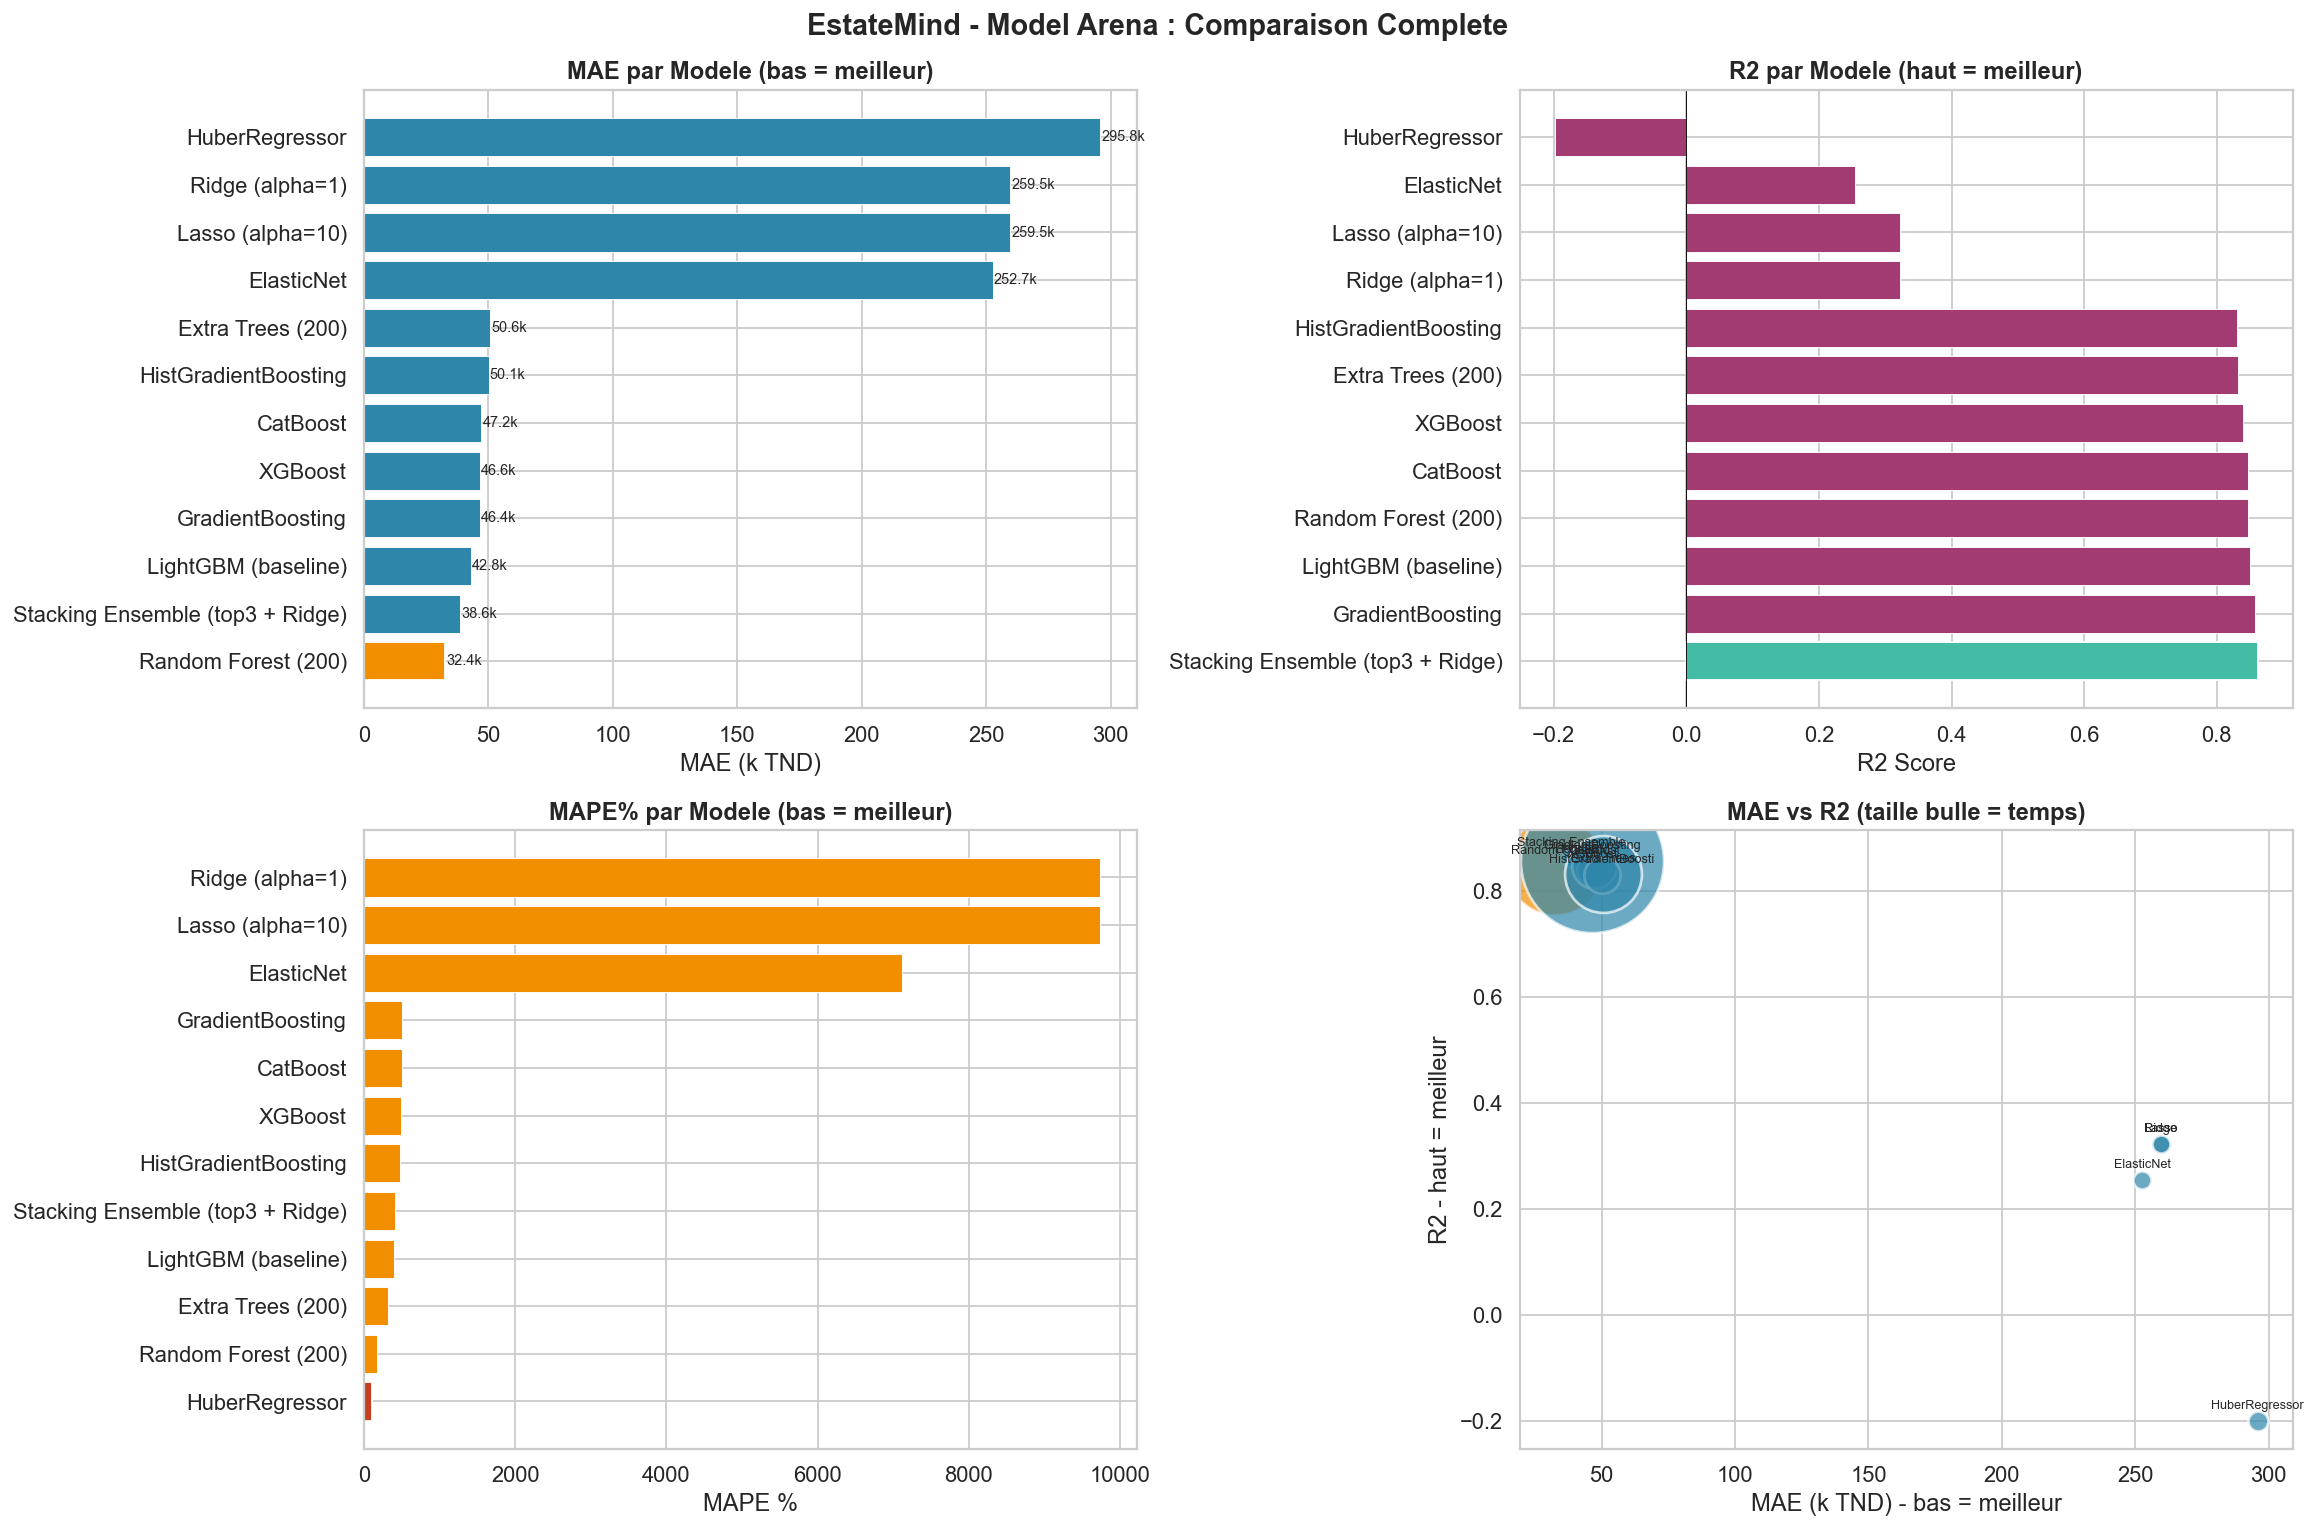

Graphique sauvegarde: estate-mind/model_arena_comparison.png


In [26]:
# =========================================================
# VISUALISATION COMPARAISON - Graphiques complets
# =========================================================
from pathlib import Path

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('EstateMind - Model Arena : Comparaison Complete', fontsize=16, fontweight='bold')

colors = [PALETTE[0] if i > 0 else '#F18F01' for i in range(len(arena_df))]
colors_rev = list(reversed(colors))

# 1. MAE Comparison (horizontal bar)
ax = axes[0, 0]
sorted_df = arena_df.sort_values('MAE', ascending=True)
bars = ax.barh(sorted_df['Model'], sorted_df['MAE'] / 1000, color=PALETTE[0], edgecolor='white', lw=0.5)
# Highlight best
ax.barh(sorted_df['Model'].iloc[0], sorted_df['MAE'].iloc[0] / 1000, color='#F18F01', edgecolor='white')
for i, (bar, val) in enumerate(zip(bars, sorted_df['MAE'])):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val/1000:.1f}k', va='center', fontsize=8)
ax.set_xlabel('MAE (k TND)'); ax.set_title('MAE par Modele (bas = meilleur)', fontweight='bold')
ax.axvline(x=0, color='black', lw=0.5)

# 2. R2 Comparison
ax = axes[0, 1]
sorted_r2 = arena_df.sort_values('R2', ascending=False)
ax.barh(sorted_r2['Model'], sorted_r2['R2'], color=PALETTE[1], edgecolor='white', lw=0.5)
ax.barh(sorted_r2['Model'].iloc[0], sorted_r2['R2'].iloc[0], color='#44BBA4', edgecolor='white')
ax.set_xlabel('R2 Score'); ax.set_title('R2 par Modele (haut = meilleur)', fontweight='bold')
ax.axvline(x=0, color='black', lw=0.5)

# 3. MAPE% Comparison
ax = axes[1, 0]
sorted_mape = arena_df.sort_values('MAPE%', ascending=True)
ax.barh(sorted_mape['Model'], sorted_mape['MAPE%'], color=PALETTE[2], edgecolor='white', lw=0.5)
ax.barh(sorted_mape['Model'].iloc[0], sorted_mape['MAPE%'].iloc[0], color='#C73E1D', edgecolor='white')
ax.set_xlabel('MAPE %'); ax.set_title('MAPE% par Modele (bas = meilleur)', fontweight='bold')

# 4. Bubble chart: MAE vs R2 (taille = training time)
ax = axes[1, 1]
for _, row in arena_df.iterrows():
    size = max(row['Time_s'] * 50, 100)
    color = '#F18F01' if row['MAE'] == arena_df['MAE'].min() else PALETTE[0]
    ax.scatter(row['MAE'] / 1000, row['R2'], s=size, color=color, alpha=0.7, edgecolor='white', lw=1.5)
    ax.annotate(row['Model'].split('(')[0].strip()[:18], (row['MAE']/1000, row['R2']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')
ax.set_xlabel('MAE (k TND) - bas = meilleur')
ax.set_ylabel('R2 - haut = meilleur')
ax.set_title('MAE vs R2 (taille bulle = temps)', fontweight='bold')

plt.tight_layout()
plt.savefig('estatemind/model_arena_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegarde: estate-mind/model_arena_comparison.png')


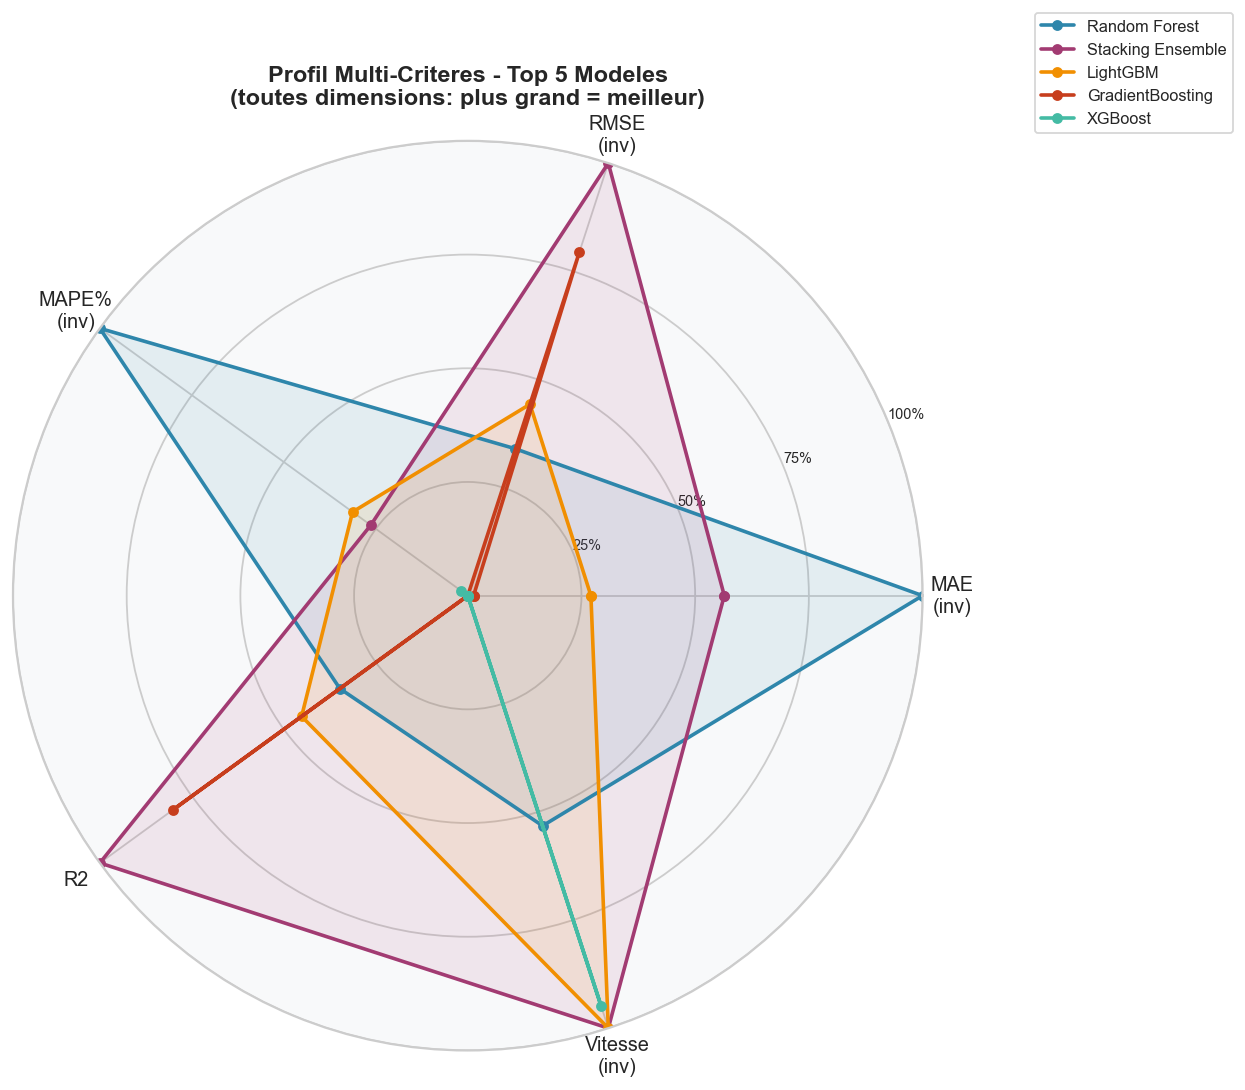

Radar chart sauvegarde: estate-mind/radar_top5_models.png


In [28]:
# =========================================================
# RADAR CHART - Profil multi-criteres des top 5 modeles
# =========================================================
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

top5 = arena_df.head(5).copy()

# Normalize metrics: higher = better (invert MAE, RMSE, MAPE)
def norm_inv(series): return 1 - (series - series.min()) / (series.max() - series.min() + 1e-9)
def norm(series):     return (series - series.min()) / (series.max() - series.min() + 1e-9)

categories = ['MAE\n(inv)', 'RMSE\n(inv)', 'MAPE%\n(inv)', 'R2', 'Vitesse\n(inv)']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
ax.set_facecolor('#f8f9fa')

palette_radar = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#44BBA4']

for idx, (_, row) in enumerate(top5.iterrows()):
    mae_n   = float(norm_inv(top5['MAE'])[top5.index == row.name])
    rmse_n  = float(norm_inv(top5['RMSE'])[top5.index == row.name])
    mape_n  = float(norm_inv(top5['MAPE%'])[top5.index == row.name])
    r2_n    = float(norm(top5['R2'])[top5.index == row.name])
    time_n  = float(norm_inv(top5['Time_s'].clip(lower=0.1))[top5.index == row.name])
    values  = [mae_n, rmse_n, mape_n, r2_n, time_n] + [mae_n]

    ax.plot(angles, values, 'o-', linewidth=2, color=palette_radar[idx], markersize=5, label=row['Model'].split('(')[0].strip()[:20])
    ax.fill(angles, values, alpha=0.1, color=palette_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8)
ax.set_ylim(0, 1)
ax.set_title('Profil Multi-Criteres - Top 5 Modeles\n(toutes dimensions: plus grand = meilleur)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig('estatemind/radar_top5_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Radar chart sauvegarde: estate-mind/radar_top5_models.png')


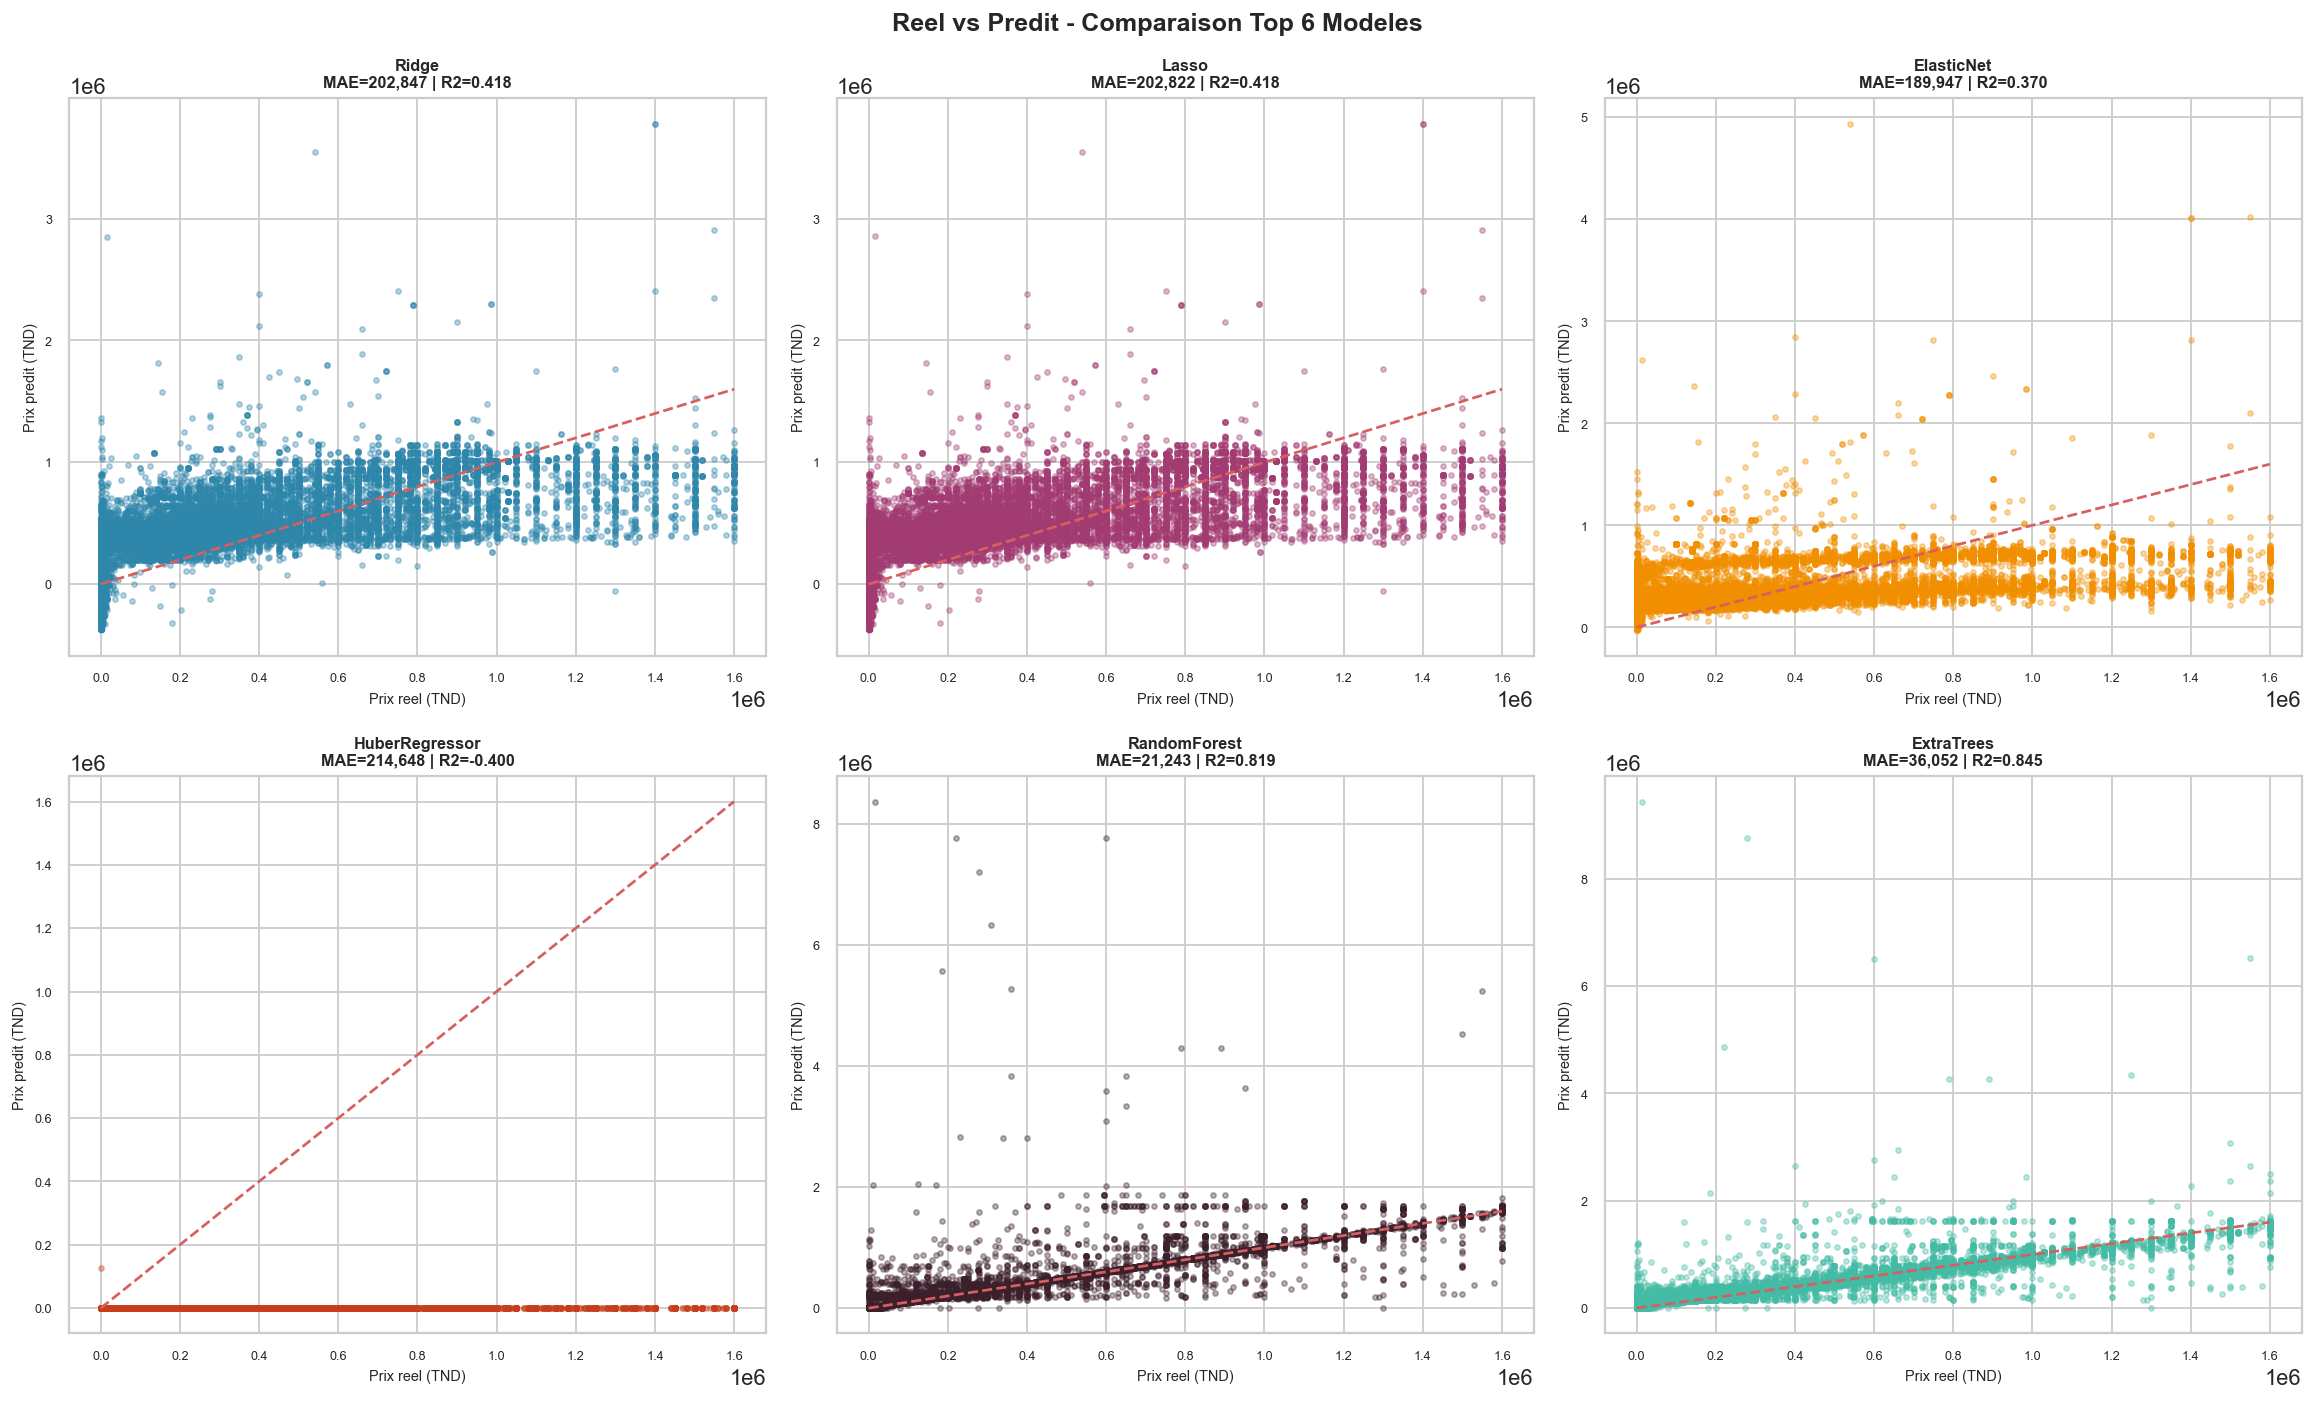

Graphique predictions sauvegarde


In [30]:
# =========================================================
# COMPARAISON PREDICTIONS - Reel vs Predit pour top modeles
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Reel vs Predit - Comparaison Top 6 Modeles', fontsize=14, fontweight='bold')
axes = axes.flatten()

models_to_show = list(arena_preds.keys())[:6]
clip_q = float(np.quantile(y_te, 0.97))

for i, model_name in enumerate(models_to_show):
    ax = axes[i]
    preds = arena_preds[model_name]
    mask  = y_te <= clip_q
    mae_m = mean_absolute_error(y_te[mask], preds[mask])
    r2_m  = r2_score(y_te[mask], preds[mask])

    ax.scatter(y_te[mask].values, preds[mask], alpha=0.35, s=8, color=PALETTE[i % len(PALETTE)])
    lo, hi = float(y_te[mask].min()), float(y_te[mask].max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Parfait')
    ax.set_title(f'{model_name}\nMAE={mae_m:,.0f} | R2={r2_m:.3f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Prix reel (TND)', fontsize=8)
    ax.set_ylabel('Prix predit (TND)', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('estatemind/predictions_top6_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique predictions sauvegarde')


## 6. Save Best Model

In [ ]:
import joblib

# Save the best LightGBM model
joblib.dump(lgbm, "estatemind_price_best_model.pkl")
print("Model saved as 'estatemind_price_best_model.pkl'")

Model saved as 'estatemind_price_model_lgbm.pkl'


## 7. Price Gap Analysis

        actual_price  predicted_price     price_gap  price_gap_pct
56529          600.0      1534.957332   -934.957332    -155.826222
49480          900.0       805.480873     94.519127      10.502125
33463         2600.0       -71.871719   2671.871719     102.764297
171059      160000.0    158479.840396   1520.159604       0.950100
202559      430000.0    464740.363801 -34740.363801      -8.079154
48955         1300.0       -88.430354   1388.430354     106.802335
2494        240000.0    238209.268018   1790.731982       0.746138
140672       95000.0     73789.393064  21210.606936      22.326955
98227       300000.0    233818.391927  66181.608073      22.060536
150075       60000.0     57739.098445   2260.901555       3.768169


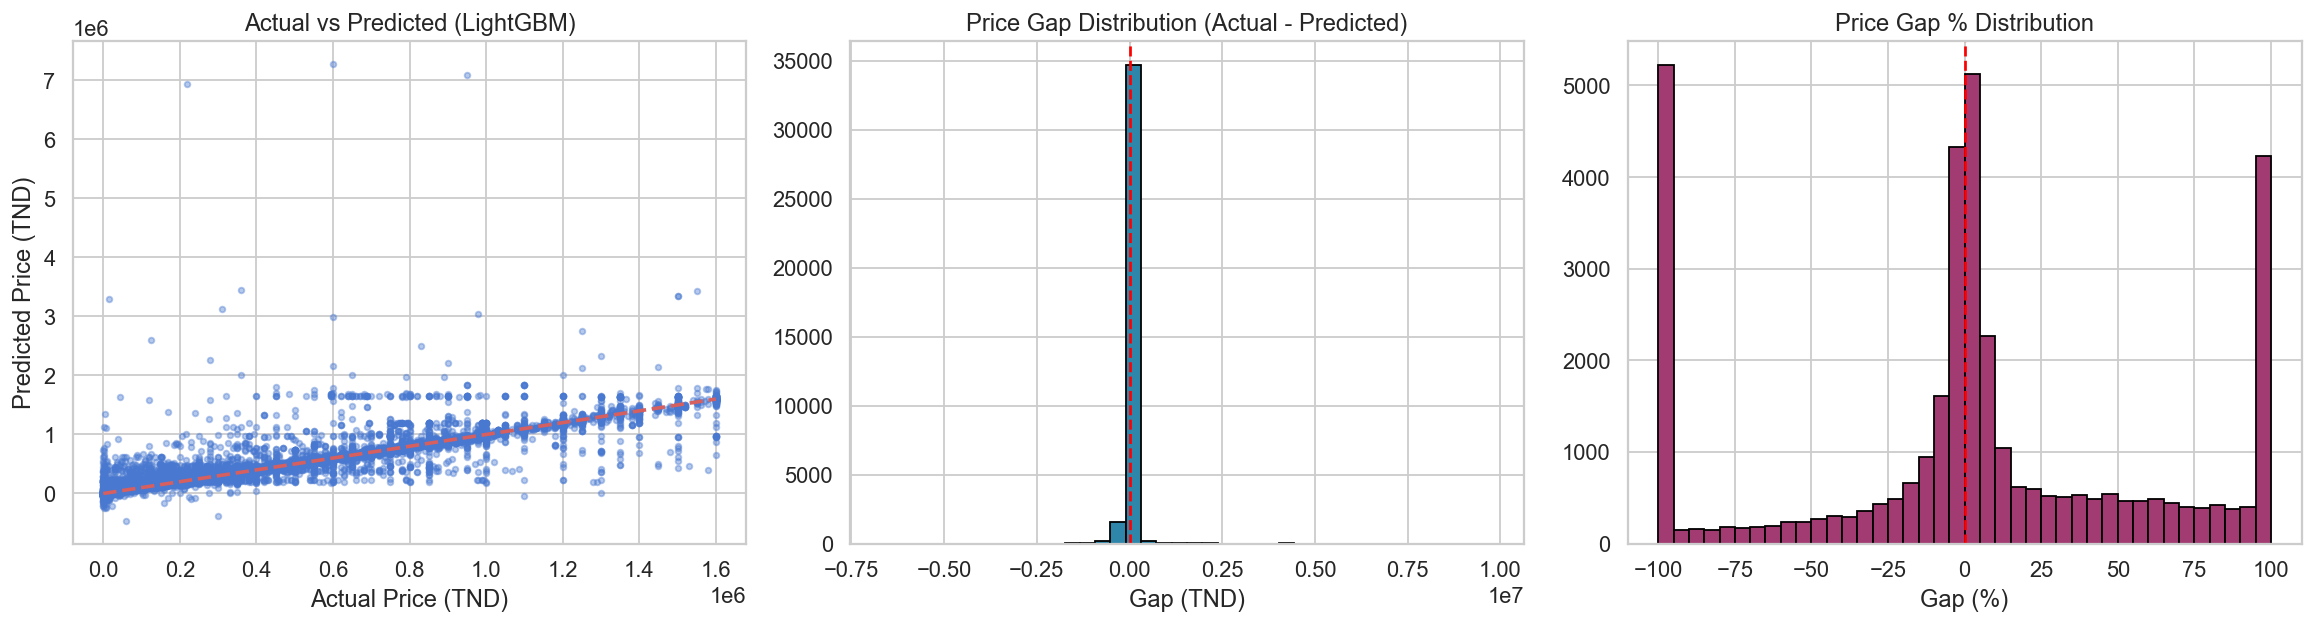

        price_gap  price_gap_pct
count    36875.00       36875.00
mean       279.25        -179.99
std     257804.78        6382.08
min   -6708975.35     -413696.66
25%      -5018.51         -17.93
50%        360.36           1.38
75%       3907.33          39.17
max    9813878.57      370612.49


In [32]:
# Price gap analysis using LightGBM predictions
test_results = X_test_enc.copy()
test_results["actual_price"]    = y_test.values
test_results["predicted_price"] = y_pred_lgbm
test_results["price_gap"]       = test_results["actual_price"] - test_results["predicted_price"]
test_results["price_gap_pct"]   = (test_results["price_gap"] / test_results["actual_price"]) * 100

print(test_results[["actual_price","predicted_price","price_gap","price_gap_pct"]].head(10))

# Plot actual vs predicted
clip_q = float(np.quantile(y_test, 0.97))
mask   = test_results["actual_price"] <= clip_q

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(test_results.loc[mask,"actual_price"], test_results.loc[mask,"predicted_price"], alpha=0.4, s=10)
lo, hi = float(test_results.loc[mask,"actual_price"].min()), float(test_results.loc[mask,"actual_price"].max())
axes[0].plot([lo,hi],[lo,hi],"r--",lw=2)
axes[0].set_title("Actual vs Predicted (LightGBM)")
axes[0].set_xlabel("Actual Price (TND)"); axes[0].set_ylabel("Predicted Price (TND)")

axes[1].hist(test_results["price_gap"], bins=40, edgecolor="black", color=PALETTE[0])
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Price Gap Distribution (Actual - Predicted)")
axes[1].set_xlabel("Gap (TND)")

axes[2].hist(test_results["price_gap_pct"].clip(-100, 100), bins=40, edgecolor="black", color=PALETTE[1])
axes[2].axvline(0, color="red", linestyle="--")
axes[2].set_title("Price Gap % Distribution")
axes[2].set_xlabel("Gap (%)")

plt.tight_layout()
plt.show()

print(test_results[["price_gap","price_gap_pct"]].describe().round(2))

## 8. Export Predictions

In [25]:
test_results.to_csv('test_predictions.csv', index=False)
print("Predictions saved to 'test_predictions.csv'")

Predictions saved to 'test_predictions.csv'


## 9. Using the Model on New Data

In [ ]:
loaded_model = joblib.load("estatemind_price_model_lgbm.pkl")
print("Model loaded successfully.")

# Example: predict on new data
# new_data = pd.DataFrame({...})  # same features as X_train_enc
# new_data_enc = te.transform(new_data)
# prediction = loaded_model.predict(new_data_enc)
# print(f"Estimated price: {prediction[0]:,.0f} TND")